In [1]:
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector

from IPython.display import display


connection = snowflake.connector.connect(
    account="NXAUBQR-GS92621",
    user="VISHALMURLIKUMAR",
    password=getpass("Snowflake password: "),
    authenticator="username_password_mfa",
    role="SYSADMIN",
    warehouse="RETAILROCKET_WH",
    database="RETAILROCKET",
    schema="ANALYTICS",
)

try:
    with connection.cursor() as cursor:
        cursor.execute("""
            SELECT
                cohort_month,
                activity_month,
                months_since_first_seen,
                cohort_size,
                active_visitor_count,
                retention_rate,
                is_cohort_month_fully_observed,
                is_activity_month_fully_observed
            FROM RETAILROCKET.ANALYTICS.MART_MONTHLY_VISITOR_RETENTION
            ORDER BY cohort_month, activity_month
        """)

        retention = pd.DataFrame(
            cursor.fetchall(),
            columns=[
                column[0].lower()
                for column in cursor.description
            ],
        )
finally:
    connection.close()

print("Retention data loaded. Connection closed.")

Retention data loaded. Connection closed.


In [2]:
for column in ["cohort_month", "activity_month"]:
    retention[column] = pd.to_datetime(retention[column])

for column in [
    "months_since_first_seen",
    "cohort_size",
    "active_visitor_count",
    "retention_rate",
]:
    retention[column] = pd.to_numeric(retention[column])

assert not retention.empty
assert not retention.duplicated(
    ["cohort_month", "activity_month"]
).any()

assert retention["retention_rate"].between(0, 1).all()
assert (
    retention["active_visitor_count"]
    <= retention["cohort_size"]
).all()

baseline = retention.loc[
    retention["months_since_first_seen"] == 0
]

assert (
    baseline["active_visitor_count"]
    == baseline["cohort_size"]
).all()

retention["retention_pct"] = retention["retention_rate"] * 100
retention["cohort_label"] = (
    retention["cohort_month"].dt.strftime("%Y-%m")
)

display(retention.round(3))

C:\Users\visha\AppData\Local\Temp\ipykernel_32128\329584294.py:37: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(retention.round(3))


,cohort_month,activity_month,months_since_first_seen,cohort_size,active_visitor_count,retention_rate,is_cohort_month_fully_observed,is_activity_month_fully_observed,retention_pct,cohort_label
0,2015-05-01,2015-05-01,0,307574,307574,1.000,False,False,100.000,2015-05
1,2015-05-01,2015-06-01,1,307574,14643,0.048,False,True,4.761,2015-05
2,2015-05-01,2015-07-01,2,307574,8783,0.029,False,True,2.856,2015-05
3,2015-05-01,2015-08-01,3,307574,5807,0.019,False,True,1.888,2015-05
4,2015-05-01,2015-09-01,4,307574,3238,0.011,False,False,1.053,2015-05
5,2015-06-01,2015-06-01,0,299189,299189,1.000,True,True,100.000,2015-06
6,2015-06-01,2015-07-01,1,299189,12651,0.042,True,True,4.228,2015-06
7,2015-06-01,2015-08-01,2,299189,6047,0.020,True,True,2.021,2015-06
8,2015-06-01,2015-09-01,3,299189,2881,0.010,True,False,0.963,2015-06
9,2015-07-01,2015-07-01,0,355765,355765,1.000,True,True,100.000,2015-07


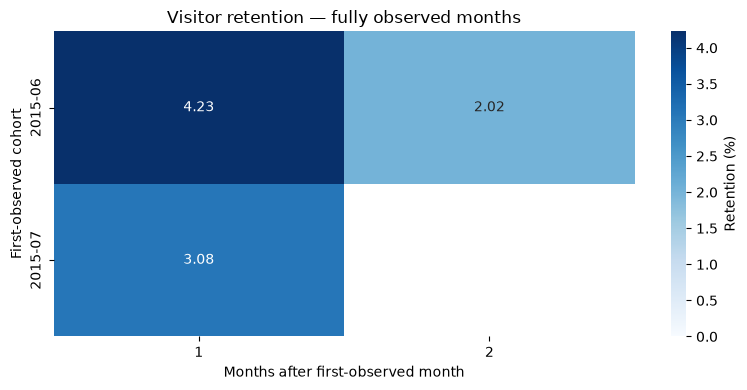

In [3]:
complete = retention.loc[
    retention["is_cohort_month_fully_observed"]
    & retention["is_activity_month_fully_observed"]
].copy()

if complete.empty:
    print("No fully observed cohort–activity combinations.")
else:
    heatmap_data = complete.pivot(
        index="cohort_label",
        columns="months_since_first_seen",
        values="retention_pct",
    ).sort_index()

    # Exclude month zero's automatic 100% baseline.
    heatmap_data = heatmap_data.drop(
        columns=0, errors="ignore"
    ).dropna(how="all")

    if heatmap_data.empty:
        print("No fully observed return months available.")
    else:
        fig, ax = plt.subplots(figsize=(8, 4))

        sns.heatmap(
            heatmap_data,
            mask=heatmap_data.isna(),
            annot=True,
            fmt=".2f",
            cmap="Blues",
            vmin=0,
            cbar_kws={"label": "Retention (%)"},
            ax=ax,
        )

        ax.set_title(
            "Visitor retention — fully observed months"
        )
        ax.set_xlabel("Months after first-observed month")
        ax.set_ylabel("First-observed cohort")

        fig.tight_layout()
        plt.show()

,cohort_label,cohort_size,active_visitor_count,retention_pct
6,2015-06,299189,12651,4.228
10,2015-07,355765,10946,3.077


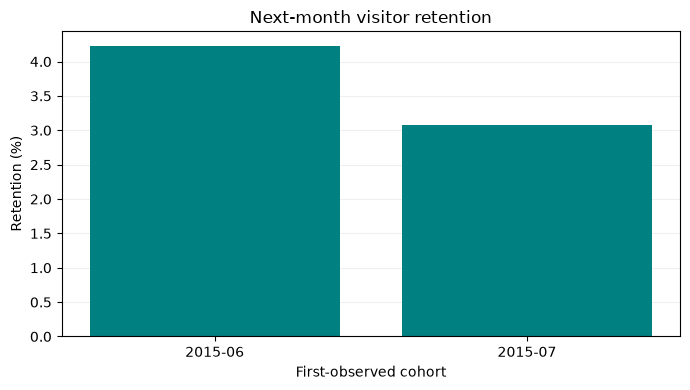

In [4]:
month_one = complete.loc[
    complete["months_since_first_seen"] == 1,
    [
        "cohort_label",
        "cohort_size",
        "active_visitor_count",
        "retention_pct",
    ],
].sort_values("cohort_label")

display(month_one.round(3))

if not month_one.empty:
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        month_one["cohort_label"],
        month_one["retention_pct"],
        color="teal",
    )

    ax.set_title("Next-month visitor retention")
    ax.set_xlabel("First-observed cohort")
    ax.set_ylabel("Retention (%)")
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

    fig.tight_layout()
    plt.show()

In [5]:
if len(month_one) >= 2:
    comparison = month_one.copy()

    comparison["change_percentage_points"] = (
        comparison["retention_pct"].diff()
    )

    comparison["relative_change_pct"] = (
        comparison["retention_pct"].pct_change(
            fill_method=None
        ) * 100
    )

    display(comparison.round(3))
else:
    print("Insufficient complete cohorts for comparison.")

,cohort_label,cohort_size,active_visitor_count,retention_pct,change_percentage_points,relative_change_pct
6,2015-06,299189,12651,4.228,NaN,NaN
10,2015-07,355765,10946,3.077,-1.152,-27.235


In [6]:
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

comparison_data = (
    month_one.set_index("cohort_label")
)

required_cohorts = ["2015-06", "2015-07"]

if not all(
    cohort in comparison_data.index
    for cohort in required_cohorts
):
    raise ValueError(
        "June and July complete next-month retention rows are required."
    )

june = comparison_data.loc["2015-06"]
july = comparison_data.loc["2015-07"]

counts = np.array([
    june["active_visitor_count"],
    july["active_visitor_count"],
], dtype=int)

sizes = np.array([
    june["cohort_size"],
    july["cohort_size"],
], dtype=int)

rates = counts / sizes

# Two-sided test: are the cohort retention proportions equal?
z_statistic, p_value = proportions_ztest(
    count=counts,
    nobs=sizes,
    alternative="two-sided",
)

# Effect is July minus June.
difference = rates[1] - rates[0]

# Approximate unpooled standard error for the difference.
difference_se = np.sqrt(
    rates[0] * (1 - rates[0]) / sizes[0]
    + rates[1] * (1 - rates[1]) / sizes[1]
)

critical_value = norm.ppf(0.975)

comparison_result = pd.DataFrame({
    "june_retention_pct": [rates[0] * 100],
    "july_retention_pct": [rates[1] * 100],
    "july_minus_june_pp": [difference * 100],
    "difference_lower_95_pp": [
        (difference - critical_value * difference_se) * 100
    ],
    "difference_upper_95_pp": [
        (difference + critical_value * difference_se) * 100
    ],
    "two_sided_p_value": [p_value],
})

display(comparison_result)
print(f"Two-sided p-value: {p_value:.3e}")

,june_retention_pct,july_retention_pct,july_minus_june_pp,difference_lower_95_pp,difference_upper_95_pp,two_sided_p_value
0,4.228431,3.07675,-1.151681,-1.243439,-1.059923,5.379407e-137


Two-sided p-value: 5.379e-137


In [7]:
print(
    f"June next-month retention: {rates[0] * 100:.3f}%\n"
    f"July next-month retention: {rates[1] * 100:.3f}%\n"
    f"July minus June: {difference * 100:.3f} percentage points"
)

print(
    "\nThis is an exploratory comparison of historical cohorts. "
    "It assumes independent visitors and does not establish "
    "that a product change caused the difference."
)

June next-month retention: 4.228%
July next-month retention: 3.077%
July minus June: -1.152 percentage points

This is an exploratory comparison of historical cohorts. It assumes independent visitors and does not establish that a product change caused the difference.


## Business findings and recommended investigations

### 1. Session purchase performance
- 0.8116% of observed sessions contained at least one purchase.
- Approximate visitor-clustered 95% confidence interval:
  0.7777%–0.8454%.
- This describes historical performance and is not a forecast.

### 2. Product funnel
- View-to-cart progression: 1.94%.
- Cart-to-purchase progression: 32.82%.
- View-to-purchase progression: 0.64%.
- The largest observed drop-off occurs before adding to cart.
- Investigate product information, discovery, and availability
  for high-traffic products with low cart progression.

### 3. Visitor retention
- June cohort next-month retention: 4.23%.
- July cohort next-month retention: 3.08%.
- July is approximately 1.15 percentage points lower.
- Investigate differences in visitor mix and first-session behavior.
- The comparison is observational and does not establish causation.

### Measurement limitations
- Cohorts represent first observed activity, not proven acquisition dates.
- May and September are partial observation months.
- Funnel journeys are session–product pairs, not orders or visitors.
- Product labels are generated from anonymized item IDs.
- Revenue and purchased quantities are unavailable.